# Mean Shift — сдвиг среднего (метод кластеризации)

## 1. Название и краткая информация о сдаваемом методе (1 абзац)

**Сдвиг среднего** (англ. *Mean Shift*, читается «мин-шифт», дословно — «сдвиг среднего») — это алгоритм **кластеризации без учителя** (*unsupervised learning*, обучение без учителя: модели заранее не сообщают, к какому классу относится объект, она сама ищет группы в данных). Идея метода очень наглядна: для каждой точки алгоритм берёт всех её соседей в пределах окна заданного радиуса (этот радиус называется **bandwidth** — «ширина окна»), считает среднее положение этих соседей и сдвигает точку в это среднее. Процесс повторяется итеративно до тех пор, пока точки не перестанут двигаться — они сходятся в **моды** (*modes* — локальные максимумы плотности данных). Все точки, сошедшиеся в одну и ту же моду, образуют один кластер, а число кластеров метод определяет **автоматически**, без предварительного задания. У Mean Shift есть два главных преимущества: он умеет находить кластеры **произвольной формы** и сам подбирает их количество. Главный параметр — ширина окна `bandwidth`: меньше значение → больше кластеров, больше значение → кластеры сливаются. Для её автоматической оценки в scikit-learn есть вспомогательная функция `estimate_bandwidth`. Как и другие методы, основанные на расстояниях, Mean Shift чувствителен к масштабу признаков, поэтому перед применением их **обязательно стандартизируют**.

## 2. Блок с используемыми библиотеками

Короткие пояснения к англоязычным названиям:
- **numpy** (читается «нам-пай») — библиотека для численных операций с массивами.
- **pandas** (читается «панд-эс») — таблицы (DataFrame, «дата-фрейм») и удобная работа с данными.
- **matplotlib** — базовая библиотека графиков.
- **seaborn** (читается «си-борн») — красивые статистические графики поверх matplotlib (в том числе тепловая карта).
- **scikit-learn** (читается «сайкит-лёрн») — библиотека машинного обучения: готовые датасеты, модели и метрики.
- **MeanShift** — сам алгоритм «сдвиг среднего» в scikit-learn.
- **estimate_bandwidth** — вспомогательная функция, которая автоматически подбирает разумную ширину окна по данным (параметр **quantile** — «квантиль», доля ближайших пар точек, по которым она оценивается).
- **StandardScaler** — стандартизатор: приводит признаки к одному масштабу (среднее 0, разброс 1). Для Mean Shift это обязательный шаг.
- **PCA** (*Principal Component Analysis* — «метод главных компонент») — способ сжать много признаков в 2 для наглядной картинки.
- **silhouette_score, silhouette_samples** — силуэтная оценка качества кластеризации (по 2D-геометрии кластеров).
- **adjusted_rand_score (ARI), normalized_mutual_info_score (NMI)** — метрики совпадения найденных кластеров с истинными метками классов.

In [1]:
# Если вы запускаете в Google Colab, обычно всё уже установлено.
# Этот блок оставлен для надёжности: установит пакеты, если их вдруг нет.
# !pip -q install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Набор данных и вспомогательные инструменты
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Сам алгоритм и автоматическая оценка ширины окна
from sklearn.cluster import MeanShift, estimate_bandwidth

# Метрики качества кластеризации
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)

# Для повторяемости результатов
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 3. Блок с описанием и демонстрацией (частичной распечаткой) используемого датасета

В качестве примера возьмём классический встроенный датасет **Iris** (в переводе — «Ирисы»), знаменитый набор ирисов Фишера из `scikit-learn`. Это набор из 150 цветков трёх видов ириса (*setosa* — щетинистый, *versicolor* — разноцветный, *virginica* — виргинский), для каждого из которых измерены 4 числовых признака в сантиметрах:
- `sepal length` — длина чашелистика,
- `sepal width` — ширина чашелистика,
- `petal length` — длина лепестка,
- `petal width` — ширина лепестка.

Важное замечание: Mean Shift — метод **без учителя**, поэтому истинные метки видов он **не использует** при обучении. Мы применим их только **в конце**, чтобы сравнить найденные кластеры с настоящими видами и оценить качество. Датасет встроен в scikit-learn — ничего скачивать не нужно, ноутбук сразу запускается в Google Colab.

In [2]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = pd.Series(data.target, name="target")          # настоящие метки видов: 0, 1, 2
target_names = list(data.target_names)                   # ['setosa', 'versicolor', 'virginica']

df = X.copy()
df["target"] = y_true

print("Размерность датасета (строк, столбцов):", df.shape)
print("Имена видов (классов):", target_names)
print("\nРаспределение настоящих классов (сколько цветков каждого вида):")
print(y_true.value_counts().sort_index())

print("\nПервые 5 строк датасета:")
display(df.head(5))

print("\nОписательная статистика по признакам:")
display(df.describe().T)

Размерность датасета (строк, столбцов): (150, 5)
Имена видов (классов): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Распределение настоящих классов (сколько цветков каждого вида):
target
0    50
1    50
2    50
Name: count, dtype: int64

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Описательная статистика по признакам:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


**Пояснение к таблицам:** каждая строка — один цветок, 4 числовых столбца — его геометрические признаки в см, а `target` — это правильный вид (0 = *setosa*, 1 = *versicolor*, 2 = *virginica*). Напомним ещё раз: `target` нужен только для финальной проверки качества кластеризации — в обучение Mean Shift он не подаётся.

## 4. Блок с предварительной обработкой датасета

Что делаем:
1. Проверяем **пропуски** (пустые значения) и **дубликаты** (повторяющиеся строки).
2. **Стандартизируем признаки** через `StandardScaler` — приводим каждый столбец к нулевому среднему и единичному разбросу. Для Mean Shift это **обязательный** шаг, потому что алгоритм опирается на расстояния между точками: если один признак измеряется в десятках, а другой — в единицах, окно будет «съезжать» в сторону крупного признака и плотностные моды исказятся.
3. В отличие от методов с учителем, здесь **не делим данные на train/test**: кластеризация ищет группы во всём наборе данных сразу.

In [3]:
# 1) Пропуски
missing = df.isna().sum().sort_values(ascending=False)
print("Пропуски по каждому столбцу (если везде 0 — пропусков нет):")
print(missing)

# 2) Дубликаты
dup_count = df.duplicated().sum()
print("\nКоличество полностью совпадающих строк (дубликатов):", dup_count)

# 3) Стандартизация признаков (очень важна для Mean Shift)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

print("\nРазмерность X после стандартизации:", X_scaled.shape)
print("\nПервые 5 строк после стандартизации (среднее ~ 0, разброс ~ 1):")
display(X_scaled.head(5))

print("\nСредние и стандартные отклонения после стандартизации (для проверки):")
display(pd.DataFrame({
    "среднее": X_scaled.mean().round(3),
    "ст. отклонение": X_scaled.std().round(3),
}))

Пропуски по каждому столбцу (если везде 0 — пропусков нет):
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Количество полностью совпадающих строк (дубликатов): 1

Размерность X после стандартизации: (150, 4)

Первые 5 строк после стандартизации (среднее ~ 0, разброс ~ 1):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444



Средние и стандартные отклонения после стандартизации (для проверки):


,среднее,ст. отклонение
sepal length (cm),-0.0,1.003
sepal width (cm),-0.0,1.003
petal length (cm),-0.0,1.003
petal width (cm),-0.0,1.003


## 5. Блок с тепловой картой

Тепловая карта (*heatmap* — «карта тепла») корреляций показывает, **насколько сильно связаны** друг с другом признаки. Значение корреляции меняется от -1 до 1:
- около 1 — сильная прямая связь (растёт один — растёт другой),
- около -1 — сильная обратная связь,
- около 0 — линейной связи почти нет.

Для кластеризации сильно скоррелированные признаки означают, что они несут похожую информацию. Это не мешает Mean Shift работать, но полезно понимать структуру данных.

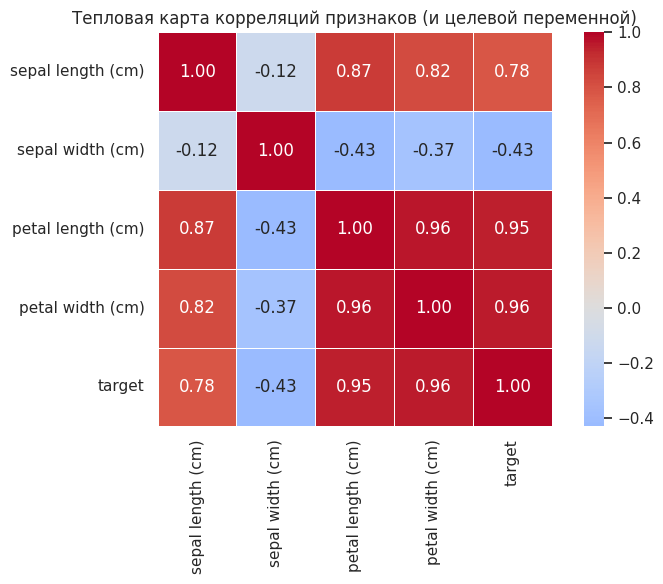

Корреляции признаков с target (по убыванию модуля):
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: target, dtype: float64


In [4]:
# Корреляции считаем по всему датасету (включая target — только для наглядности).
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,         # подписываем значения
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Тепловая карта корреляций признаков (и целевой переменной)")
plt.tight_layout()
plt.show()

print("Корреляции признаков с target (по убыванию модуля):")
print(
    corr["target"]
    .drop("target")
    .reindex(corr["target"].drop("target").abs().sort_values(ascending=False).index)
)

## 6. Блок с обучением модели

Главный параметр Mean Shift — **bandwidth** (ширина окна), радиус окрестности, в которой алгоритм считает среднее положение точек. Подбираем его двумя способами:

1. **Автоматически через `estimate_bandwidth`** — функция принимает параметр **quantile** (квантиль): это доля пар точек, расстояние между которыми меньше ширины окна. Типичные значения — от 0.1 до 0.5. Меньший квантиль → уже окно → больше кластеров.
2. **Ручной перебор** нескольких квантилей от 0.1 до 0.5 с шагом 0.05. Для каждого значения оцениваем ширину окна, обучаем `MeanShift` и считаем метрики: ARI, NMI и силуэтную оценку.

Из перебранных значений выбираем то, которое даёт наибольший ARI (наилучшее совпадение найденных кластеров с настоящими видами), и используем его для итоговой модели.

In [5]:
# --- Шаг 1. Перебор quantile и сводная таблица ---
quantiles = np.round(np.arange(0.10, 0.51, 0.05), 2)
X_arr = X_scaled.values

rows = []
for q in quantiles:
    bw = estimate_bandwidth(X_arr, quantile=q, random_state=RANDOM_STATE)
    if bw <= 0:
        # Пропуск: слишком маленький квантиль для данного датасета
        continue
    model_q = MeanShift(bandwidth=bw, bin_seeding=True)
    labels_q = model_q.fit_predict(X_arr)
    n_clusters_q = len(np.unique(labels_q))
    # Силуэтная мера требует как минимум 2 кластера
    if 2 <= n_clusters_q < len(X_arr):
        sil_q = silhouette_score(X_arr, labels_q)
    else:
        sil_q = np.nan
    ari_q = adjusted_rand_score(y_true, labels_q)
    nmi_q = normalized_mutual_info_score(y_true, labels_q)
    rows.append({
        "quantile": q,
        "bandwidth": round(bw, 3),
        "кластеров": n_clusters_q,
        "ARI": round(ari_q, 4),
        "NMI": round(nmi_q, 4),
        "silhouette": round(sil_q, 4) if not np.isnan(sil_q) else np.nan,
    })

sweep_df = pd.DataFrame(rows)
print("Сводная таблица по перебранным значениям quantile:")
display(sweep_df)

Сводная таблица по перебранным значениям quantile:


,quantile,bandwidth,кластеров,ARI,NMI,silhouette
0,0.10,0.851,7,0.5651,0.5895,0.3625
1,0.15,1.030,4,0.5373,0.6620,0.3603
2,0.20,1.207,3,0.5600,0.7036,0.4325
3,0.25,1.389,3,0.5596,0.7056,0.4380
4,0.30,1.602,2,0.5681,0.7337,0.5818
5,0.35,1.919,2,0.5681,0.7337,0.5818
6,0.40,2.090,2,0.5681,0.7337,0.5818
7,0.45,2.225,2,0.5681,0.7337,0.5818
8,0.50,2.409,2,0.5681,0.7337,0.5818


In [6]:
# --- Шаг 2. Выбираем лучший quantile по ARI и обучаем итоговую модель ---
valid = sweep_df[sweep_df["кластеров"] >= 2].copy()
best_row = valid.loc[valid["ARI"].idxmax()]
best_q = float(best_row["quantile"])
best_bw = float(best_row["bandwidth"])

print(f"Лучшая комбинация: quantile = {best_q}, bandwidth = {best_bw}")
print(f"Число найденных кластеров: {int(best_row['кластеров'])}")

# Итоговая модель на всём датасете
mean_shift = MeanShift(bandwidth=best_bw, bin_seeding=True)
cluster_labels = mean_shift.fit_predict(X_arr)

centers = mean_shift.cluster_centers_
n_clusters = len(np.unique(cluster_labels))

print(f"\nПараметры итоговой модели: bandwidth = {best_bw}")
print(f"Найдено кластеров (автоматически): {n_clusters}")
print(f"Размер массива центров кластеров: {centers.shape}")

print("\nРаспределение объектов по найденным кластерам:")
print(pd.Series(cluster_labels, name="кластер").value_counts().sort_index())

print("\nКоординаты центров кластеров в стандартизованном пространстве:")
display(pd.DataFrame(centers, columns=X.columns).round(3))

Лучшая комбинация: quantile = 0.3, bandwidth = 1.602
Число найденных кластеров: 2

Параметры итоговой модели: bandwidth = 1.602
Найдено кластеров (автоматически): 2
Размер массива центров кластеров: (2, 4)

Распределение объектов по найденным кластерам:
кластер
0    100
1     50
Name: count, dtype: int64

Координаты центров кластеров в стандартизованном пространстве:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.485,-0.320,0.646,0.649
1,-1.060,0.758,-1.300,-1.254


**Пояснение к параметрам модели Mean Shift:**
- `bandwidth` — ширина окна. Меньше → больше мелких кластеров. Больше → кластеры сливаются в один.
- `bin_seeding=True` — ускоряющий приём: алгоритм стартует не из каждой точки, а из центров ячеек сетки (bin — «корзина»). На качество почти не влияет, но заметно быстрее.

Полезные атрибуты обученной модели:
- `labels_` — метки кластеров для каждой точки (целые числа от 0 до `n_clusters - 1`).
- `cluster_centers_` — координаты центров найденных кластеров.
- `predict(X_new)` — присвоить кластер новым точкам (по ближайшему центру).

## 7. Блок с прогнозами модели

Так как Mean Shift — метод **без учителя**, «прогноз» здесь — это номер кластера, который модель присвоила каждому объекту (в отличие от DBSCAN, шумовой метки `-1` здесь нет — каждый объект обязательно попадает в какой-то кластер). Оценим качество кластеризации сразу несколькими способами:

- **silhouette_score** (*силуэтная оценка*) — насколько точки внутри одного кластера плотные и насколько далеко от других кластеров. Значение от -1 до 1; ближе к 1 — лучше.
- **adjusted_rand_score (ARI, скорректированный индекс Рэнда)** — сравнивает найденные кластеры с настоящими метками. 1 — идеальное совпадение, 0 — как случайное угадывание.
- **normalized_mutual_info_score (NMI, нормированная взаимная информация)** — тоже сравнивает с истиной, значение от 0 до 1; чем больше — тем лучше.
- **confusion_matrix (таблица сопряжённости)** — наглядное сопоставление «истинный вид × номер кластера», чтобы увидеть, какой кластер какому виду соответствует.

Дополнительно покажем, как метод `predict` присваивает кластер **новым** точкам, на небольшой случайной выборке.

In [7]:
# Метрики, сравнивающие с настоящими метками (внешние метрики)
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print(f"Adjusted Rand Index (ARI):            {ari:.4f}")
print(f"Normalized Mutual Information (NMI):  {nmi:.4f}")

if n_clusters >= 2:
    sil = silhouette_score(X_arr, cluster_labels)
    print(f"Silhouette score (силуэтная мера):    {sil:.4f}")
else:
    sil = None
    print("Silhouette score посчитать нельзя: найден всего 1 кластер.")

# Таблица сопряжённости «истинный вид × номер кластера»
crosstab = pd.crosstab(
    pd.Series(y_true.map(dict(enumerate(target_names))), name="Истинный вид"),
    pd.Series(cluster_labels, name="Кластер Mean Shift"),
)
print("\nТаблица сопряжённости (истинный вид × найденный кластер):")
display(crosstab)

# Частичная распечатка прогнозов
preview = pd.DataFrame({
    "истинный вид": y_true.map(dict(enumerate(target_names))).values,
    "номер кластера": cluster_labels,
})
# Покажем перемешанную выборку, чтобы в превью попали все виды
preview_sample = preview.sample(n=15, random_state=RANDOM_STATE).reset_index(drop=True)
print("\nПример прогнозов (15 случайных объектов):")
display(preview_sample)

# Демонстрация метода predict на «новых» точках — возьмём 5 случайных объектов,
# как будто они только что пришли из внешнего источника (и к ним уже применена стандартизация).
rng = np.random.default_rng(RANDOM_STATE)
new_idx = rng.choice(len(X_arr), size=5, replace=False)
X_new = X_arr[new_idx]
predicted_new = mean_shift.predict(X_new)

print("\nПрисвоение кластеров новым точкам через метод predict:")
display(pd.DataFrame({
    "индекс": new_idx,
    "истинный вид": [target_names[y_true.iloc[i]] for i in new_idx],
    "присвоенный кластер": predicted_new,
}))

Adjusted Rand Index (ARI):            0.5681
Normalized Mutual Information (NMI):  0.7337
Silhouette score (силуэтная мера):    0.5818

Таблица сопряжённости (истинный вид × найденный кластер):


Кластер Mean Shift,0,1
Истинный вид,,
setosa,0,50
versicolor,50,0
virginica,50,0



Пример прогнозов (15 случайных объектов):


,истинный вид,номер кластера
0,versicolor,0
1,setosa,1
2,virginica,0
3,versicolor,0
4,versicolor,0
5,setosa,1
6,versicolor,0
7,virginica,0
8,versicolor,0
9,versicolor,0



Присвоение кластеров новым точкам через метод predict:


,индекс,истинный вид,присвоенный кластер
0,113,virginica,0
1,65,versicolor,0
2,96,versicolor,0
3,13,setosa,1
4,64,versicolor,0


**Как читать метрики:**
- На датасете Iris у Mean Shift типично получается **2 кластера** (не 3). Причина: *setosa* отделена от других видов очень чётко, а *versicolor* и *virginica* плотно перекрываются по признакам, и Mean Shift обычно объединяет их в одну моду. Это отражает реальную плотностную структуру данных.
- Чтобы получить 3 кластера, нужна более узкая ширина окна (меньший `quantile`), но силуэтная мера и ARI при этом могут ухудшиться — моды начинают дробиться на искусственные подкластеры.
- В таблице сопряжённости видно, сколько цветков каждого вида попало в каждый найденный кластер — это помогает интерпретировать результат.

## 8. Блок с графиками выходных результатов

Построим четыре графика:
1. **Кластеры на плоскости PCA** (*Principal Component Analysis* — метод главных компонент, способ сжать 4 признака в 2 для наглядности). Отметим также центры кластеров.
2. **Сравнение бок-о-бок**: настоящие виды ирисов и найденные кластеры на той же плоскости PCA.
3. **Силуэтный график** — для каждой точки показывает, насколько уверенно она попала в свой кластер.
4. **Чувствительность Mean Shift к ширине окна** — как меняются число кластеров, ARI, NMI и силуэтная мера при разных значениях `quantile` / `bandwidth`.

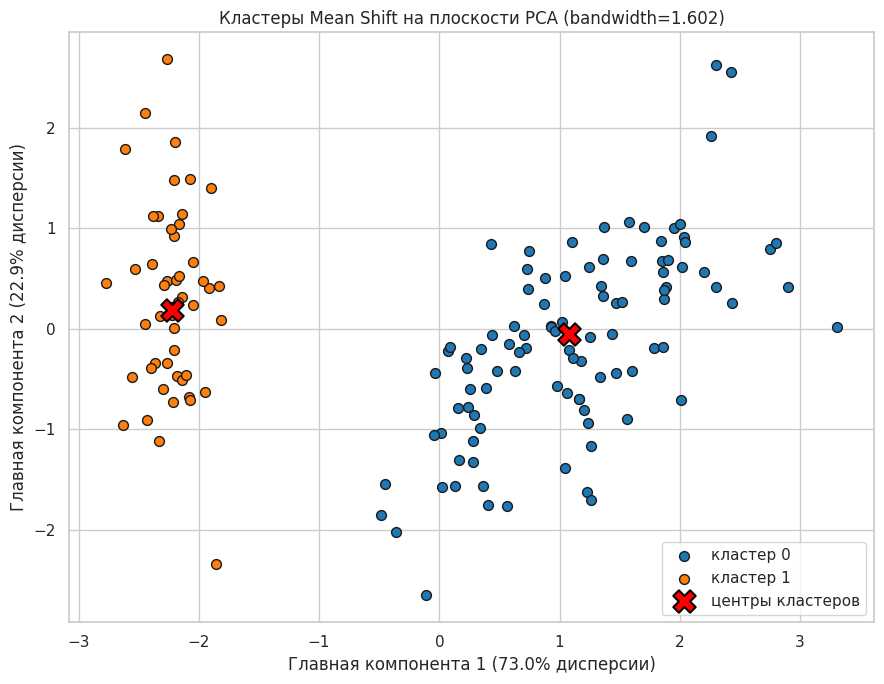

Доля объяснённой дисперсии двумя компонентами PCA: 0.958


In [8]:
# 8.1 Кластеры Mean Shift на плоскости PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_arr)
centers_pca = pca.transform(centers)
explained = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(9, 7))

unique_labels = sorted(np.unique(cluster_labels).tolist())
palette = sns.color_palette("tab10", n_colors=max(len(unique_labels), 3))

for i, lbl in enumerate(unique_labels):
    mask = cluster_labels == lbl
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=50, color=palette[i % len(palette)], edgecolor="k",
        label=f"кластер {lbl}",
    )

# Центры кластеров большими крестами
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    marker="X", s=260, c="red", edgecolor="black", linewidths=1.5,
    label="центры кластеров",
)

plt.title(f"Кластеры Mean Shift на плоскости PCA (bandwidth={best_bw})")
plt.xlabel(f"Главная компонента 1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"Главная компонента 2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Доля объяснённой дисперсии двумя компонентами PCA: {explained:.3f}")

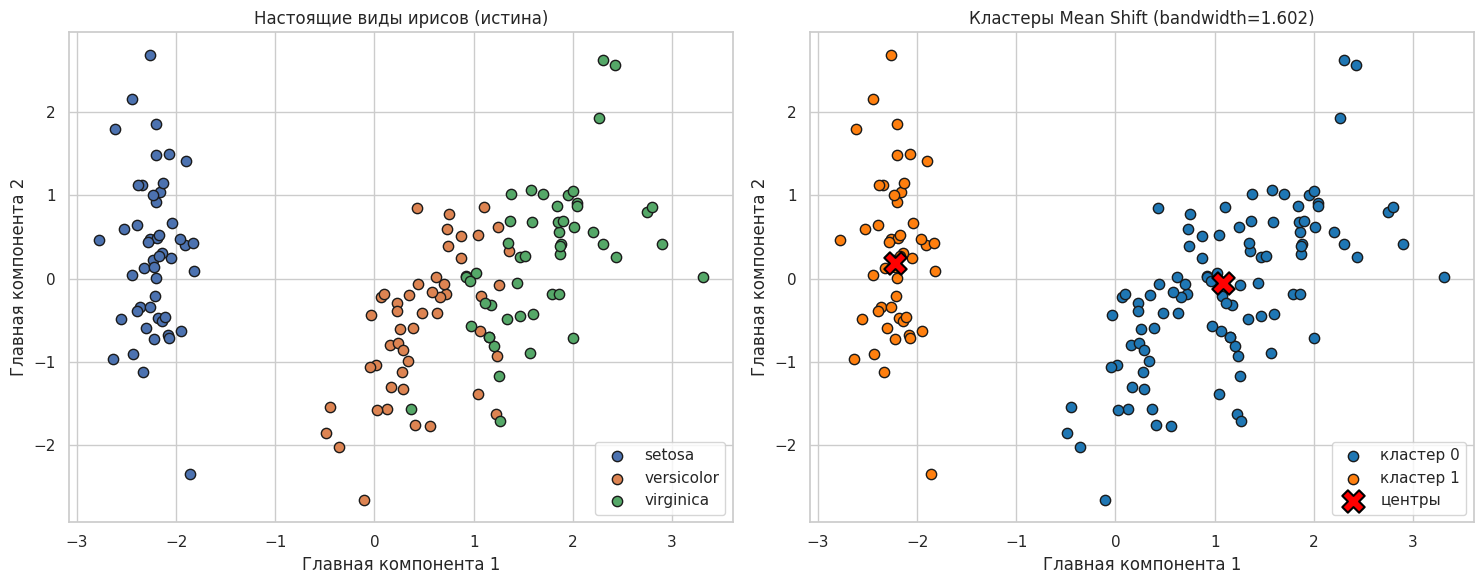

In [9]:
# 8.2 Сравнение бок-о-бок: настоящие виды и найденные кластеры
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Слева — настоящие метки видов
for i, name in enumerate(target_names):
    mask = y_true.values == i
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=55, edgecolor="k", label=name,
    )
axes[0].set_title("Настоящие виды ирисов (истина)")
axes[0].set_xlabel("Главная компонента 1")
axes[0].set_ylabel("Главная компонента 2")
axes[0].legend()
axes[0].grid(True)

# Справа — кластеры Mean Shift
for i, lbl in enumerate(unique_labels):
    mask = cluster_labels == lbl
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=55, color=palette[i % len(palette)], edgecolor="k",
        label=f"кластер {lbl}",
    )
axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    marker="X", s=260, c="red", edgecolor="black", linewidths=1.5,
    label="центры",
)
axes[1].set_title(f"Кластеры Mean Shift (bandwidth={best_bw})")
axes[1].set_xlabel("Главная компонента 1")
axes[1].set_ylabel("Главная компонента 2")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

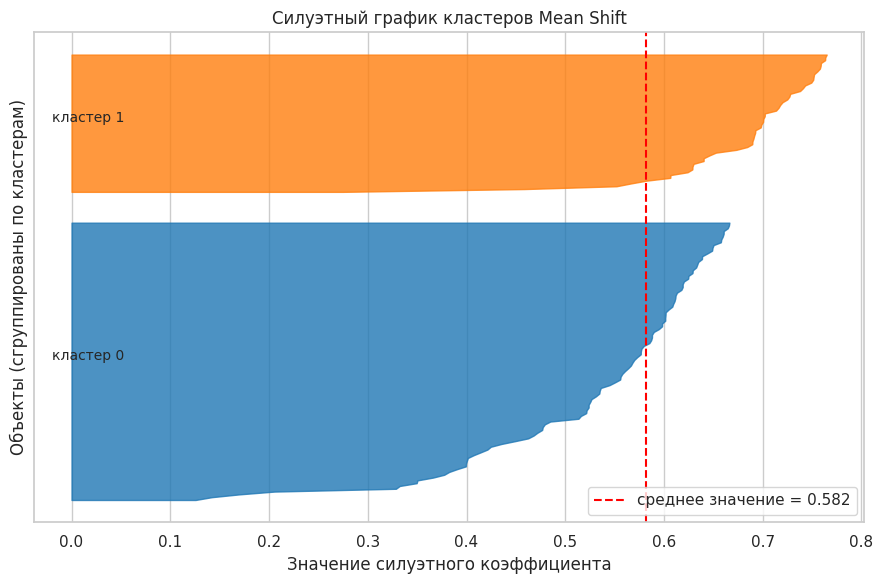

In [10]:
# 8.3 Силуэтный график
# Силуэтный коэффициент для каждой точки: 1 — идеально своя, 0 — на границе, -1 — скорее чужая.

if n_clusters >= 2:
    silhouette_vals = silhouette_samples(X_arr, cluster_labels)
    avg_silhouette = silhouette_vals.mean()

    plt.figure(figsize=(9, 6))
    y_lower = 10
    for i, lbl in enumerate(unique_labels):
        vals = np.sort(silhouette_vals[cluster_labels == lbl])
        size = len(vals)
        y_upper = y_lower + size
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, vals,
            color=palette[i % len(palette)],
            alpha=0.8,
        )
        plt.text(-0.02, y_lower + 0.5 * size, f"кластер {lbl}", fontsize=10)
        y_lower = y_upper + 10

    plt.axvline(avg_silhouette, color="red", linestyle="--",
                label=f"среднее значение = {avg_silhouette:.3f}")
    plt.xlabel("Значение силуэтного коэффициента")
    plt.ylabel("Объекты (сгруппированы по кластерам)")
    plt.title("Силуэтный график кластеров Mean Shift")
    plt.legend(loc="lower right")
    plt.yticks([])
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("Силуэтный график не построен: нужно минимум 2 кластера.")

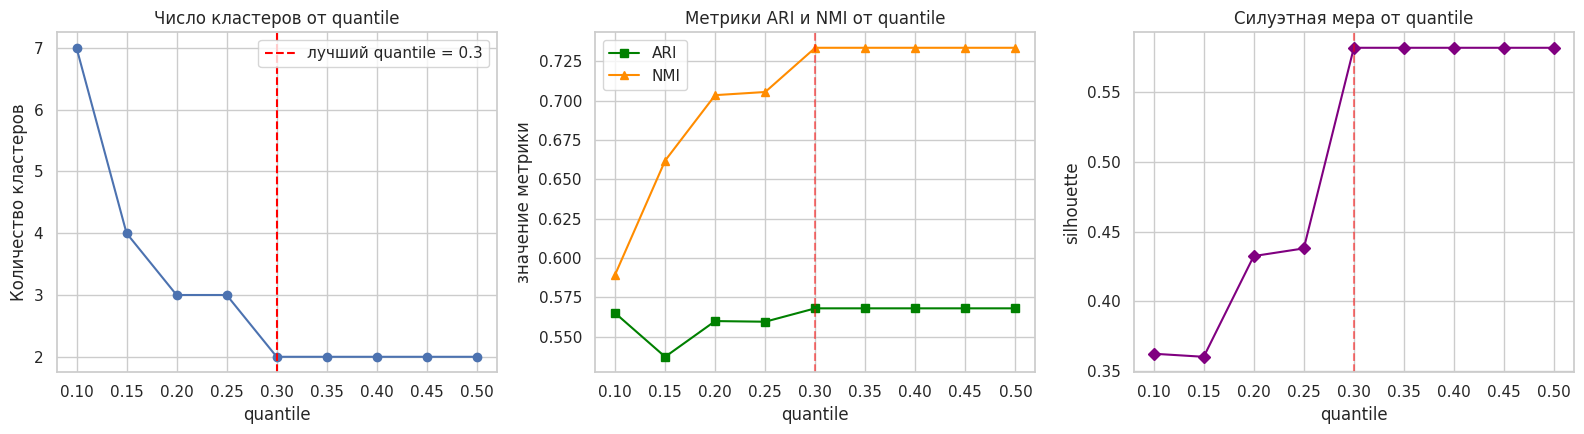

Сводная таблица по перебранным значениям quantile:


,quantile,bandwidth,кластеров,ARI,NMI,silhouette
0,0.10,0.851,7,0.5651,0.5895,0.3625
1,0.15,1.030,4,0.5373,0.6620,0.3603
2,0.20,1.207,3,0.5600,0.7036,0.4325
3,0.25,1.389,3,0.5596,0.7056,0.4380
4,0.30,1.602,2,0.5681,0.7337,0.5818
5,0.35,1.919,2,0.5681,0.7337,0.5818
6,0.40,2.090,2,0.5681,0.7337,0.5818
7,0.45,2.225,2,0.5681,0.7337,0.5818
8,0.50,2.409,2,0.5681,0.7337,0.5818


In [11]:
# 8.4 Чувствительность Mean Shift к ширине окна (через quantile)
# Уже перебранные значения лежат в sweep_df — визуализируем их.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(sweep_df["quantile"], sweep_df["кластеров"], marker="o")
axes[0].axvline(best_q, color="red", linestyle="--", label=f"лучший quantile = {best_q}")
axes[0].set_title("Число кластеров от quantile")
axes[0].set_xlabel("quantile")
axes[0].set_ylabel("Количество кластеров")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sweep_df["quantile"], sweep_df["ARI"], marker="s", color="green", label="ARI")
axes[1].plot(sweep_df["quantile"], sweep_df["NMI"], marker="^", color="darkorange", label="NMI")
axes[1].axvline(best_q, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Метрики ARI и NMI от quantile")
axes[1].set_xlabel("quantile")
axes[1].set_ylabel("значение метрики")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(sweep_df["quantile"], sweep_df["silhouette"], marker="D", color="purple")
axes[2].axvline(best_q, color="red", linestyle="--", alpha=0.5)
axes[2].set_title("Силуэтная мера от quantile")
axes[2].set_xlabel("quantile")
axes[2].set_ylabel("silhouette")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("Сводная таблица по перебранным значениям quantile:")
display(sweep_df)

---

### Короткий вывод

Алгоритм **Mean Shift (сдвиг среднего)** применён к стандартизированному датасету Iris. Параметр `bandwidth` подобран автоматически через функцию `estimate_bandwidth` с перебором нескольких значений `quantile`, и затем выбран тот, который даёт наилучший ARI. Модель без учителя **сама** нашла число кластеров и их центры — задавать их заранее не требуется.

Графики показали:
- как выглядят найденные кластеры и их центры на плоскости PCA,
- как они соотносятся с настоящими видами ирисов,
- силуэтные коэффициенты (насколько уверенно каждая точка попала в свой кластер),
- чувствительность метода к параметру `quantile` (и, значит, к ширине окна): при малых значениях кластеры дробятся, при больших — сливаются в один.

**Ключевая особенность Mean Shift:** метод основан на поиске мод плотности данных, не требует заранее задавать число кластеров и умеет находить кластеры произвольной формы. Плата за это — нужно аккуратно подбирать ширину окна `bandwidth` и обязательно стандартизировать признаки перед запуском.